<a href="https://colab.research.google.com/github/engmohammedhisham/E-Commerce-Console-System/blob/main/ETL_project_data_aquisition_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install requests bs4 selenium webdriver-manager Google-search-results -q google-colab-selenium pyvis

In [ ]:
import requests
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd
import time
import networkx as nx
import matplotlib.pyplot as plt
from serpapi import GoogleSearch
import  google_colab_selenium as gs
import seaborn as sns
import pyvis

In [ ]:
import requests
url="https://www.ebay.com/b/Cell-Phones-Smartphones/9355/bn_320094"
headers={ "User-Agent" : "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36"}
r=requests.get(url, headers=headers)
print(r)

<Response [200]>


In [ ]:
results=[]
soup=BeautifulSoup(r.content,"html5lib")
items=soup.find_all("div",class_='brwrvr__item-card__wrapper')
for item in items:
  title_found=item.find('h3',class_='textual-display bsig__title__text')
  title_element=title_found.text.strip() if title_found else 'N/A'
  price_found=item.find('span',class_='textual-display bsig__price bsig__price--displayprice')
  price_element=price_found.text.strip() if price_found else 'N/A'
  if title_element!='N/A' and price_element!='N/A':
    results.append({"product":title_element,"price":price_element})
results

[{'product': 'Shop on eBay', 'price': '$479.99'},
 {'product': 'Shop on eBay', 'price': '$479.99'},
 {'product': 'Apple iPhone 8 - (Great Condition) - Unlocked, AT&T, T-Mobile, Verizon',
  'price': '$109.99 to $174.99'},
 {'product': 'NEW Apple iPhone SE 2022 5G 3rd Gen 100% 🔋 Battery Factory 🔓 Unlocked Warranty',
  'price': '$229.00 to $449.00'},
 {'product': 'Apple iPhone 13, 128/256/512GB - Fully Unlocked - Used - All colors',
  'price': '$209.99 to $254.99'},
 {'product': 'Apple iPhone 12 Pro, 128/256/512GB - Fully Unlocked - Used Very Good',
  'price': '$259.99 to $299.99'},
 {'product': 'Apple iPhone 13 128GB Unlocked - Good', 'price': '$225.99'},
 {'product': 'Samsung Galaxy S23 128GB S911U Unlocked - Excellent',
  'price': '$238.99'},
 {'product': 'Apple iPhone 13 A2482 128GB Midnight TracFone Locked Very Good',
  'price': '$189.99'},
 {'product': 'NEW Sealed Samsung Galaxy S24 Ultra/S22 Ultra/S23 Ultra/S23+/S22+ 5G Unlocked',
  'price': '$150.00 to $459.00'},
 {'product': 'App

In [ ]:
df=pd.DataFrame(results)
df.to_csv('ebay_smart phones_by_bs4.csv',index=False)

In [ ]:
from serpapi import GoogleSearch

In [ ]:
params={
    "engine":"google_shopping",
    "q":"Smart phones ",
    "api_key":"3340e2d65f150244f55c0afd6cb5f22ce454272535f06a2c4430426ecd3c7cee"
}
search=GoogleSearch(params)

In [ ]:
products=search.get_dict()
products

{'search_metadata': {'id': '69fd1c9dd08cfe85978434d6',
  'status': 'Success',
  'json_endpoint': 'https://serpapi.com/searches/GpFk_UMbgnVq7kp2fdG3MA/69fd1c9dd08cfe85978434d6.json',
  'created_at': '2026-05-07 23:13:33 UTC',
  'processed_at': '2026-05-07 23:13:33 UTC',
  'google_shopping_url': 'https://www.google.com/search?udm=28&q=Smart+phones+&hl=en&gl=us',
  'raw_html_file': 'https://serpapi.com/searches/GpFk_UMbgnVq7kp2fdG3MA/69fd1c9dd08cfe85978434d6.html',
  'total_time_taken': 1.59},
 'search_parameters': {'engine': 'google_shopping',
  'q': 'Smart phones ',
  'google_domain': 'google.com',
  'hl': 'en',
  'gl': 'us',
  'device': 'desktop'},
 'search_information': {'query_displayed': 'Smart phones',
  'shopping_results_state': 'Results for exact spelling'},
 'shopping_results': [{'position': 1,
   'title': 'Samsung Galaxy A17 5G',
   'product_id': '7107946910101650238',
   'product_link': 'https://www.google.com/search?ibp=oshop&q=Smart phones &prds=catalogid:7107946910101650238

In [ ]:
product_result=products['shopping_results']
print(product_result)
print(len(product_result))

[{'position': 1, 'title': 'Samsung Galaxy A17 5G', 'product_id': '7107946910101650238', 'product_link': 'https://www.google.com/search?ibp=oshop&q=Smart phones &prds=catalogid:7107946910101650238,productid:17263745118909366091,headlineOfferDocid:1697651119585775799,imageDocid:4776403388657343528,rds:PC_3518113095992672625|PROD_PC_3518113095992672625,gpcid:3518113095992672625,pvt:hg&hl=en&gl=us&udm=28', 'immersive_product_page_token': 'eyJlaSI6Im5oejlhWm5sRGFPVXJ1RVBwc0Mya1F3IiwicHJvZHVjdGlkIjoiMTcyNjM3NDUxMTg5MDkzNjYwOTEiLCJjYXRhbG9naWQiOiI3MTA3OTQ2OTEwMTAxNjUwMjM4IiwiaGVhZGxpbmVPZmZlckRvY2lkIjoiMTY5NzY1MTExOTU4NTc3NTc5OSIsImltYWdlRG9jaWQiOiI0Nzc2NDAzMzg4NjU3MzQzNTI4IiwicmRzIjoiUENfMzUxODExMzA5NTk5MjY3MjYyNXxQUk9EX1BDXzM1MTgxMTMwOTU5OTI2NzI2MjUiLCJxdWVyeSI6IlNtYXJ0K3Bob25lcysiLCJncGNpZCI6IjM1MTgxMTMwOTU5OTI2NzI2MjUiLCJtaWQiOiIiLCJwdnQiOiJoZyIsInV1bGUiOm51bGwsImdsIjoidXMiLCJobCI6ImVuIn0=', 'serpapi_immersive_product_api': 'https://serpapi.com/search.json?engine=google_immersive_product&

In [ ]:
for product in product_result:
    print(product.get('position'),":",product.get('title'),":",product.get('price'))

1 : Samsung Galaxy A17 5G : $119.00
2 : Motorola Moto G Power 2024 5G : $129.99
3 : Apple iPhone 17 Pro : $36.11/mo
4 : Apple iPhone 17 : $829.00
5 : Motorola 2024 Moto G Play : $109.99
6 : Samsung Galaxy A36 5G Smartphone : $279.00
7 : Samsung Galaxy S25 FE : $452.99
8 : OnePlus 13 : $999.99
9 : Unihertz Titan 2 : $489.99
10 : Motorola Edge 2025 : $29.99
11 : Motorola Moto G 5G 2024 : $129.99
12 : Restored Apple iPhone 16 : $729.99
13 : Google Pixel 10 Pro : $749.00
14 : Samsung Galaxy S25 : $20.81/mo
15 : Motorola moto g Stylus 2025 : $399.99
16 : Samsung Galaxy A17 5G Si : $9.58/mo
17 : Apple iPhone 17e : $22.22/mo
18 : Samsung Galaxy A25 5G : $199.00
19 : Google Pixel 10 : $599.00
20 : Motorola Moto G Stylus 2025 : $8.20/mo
21 : Unihertz Jelly Max 5G Smartphone : $339.99
22 : Samsung Galaxy Note 20 128gb 5G : $214.99
23 : Google Pixel 10 Pro XL : $1,199.99
24 : Samsung Galaxy Z Flip7 : $899.99
25 : Google Pixel 9a 128GB : $499.00
26 : OnePlus 15 512GB : $999.99
27 : Samsung Galaxy 

In [ ]:
df=pd.DataFrame(product_result)
df.to_csv('Smartphones_by_serpapi.csv',index=True)

In [ ]:
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt install -y ./google-chrome-stable_current_amd64.deb
!pip install -q selenium webdriver-manager

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'google-chrome-stable' instead of './google-chrome-stable_current_amd64.deb'
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libatk-bridge2.0-0 libatk1.0-0
  libatk1.0-data libatspi2.0-0 libvulkan1 libxcomposite1 libxtst6
  mesa-vulkan-drivers session-migration
The following NEW packages will be installed:
  at-spi2-core google-chrome-stable gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libvulkan1
  libxcomposite1 libxtst6 mesa-vulkan-drivers session-migration
0 upgraded, 12 newly installed, 0 to remove and 2 not upgraded.
Need to get 11.2 MB/141 MB of archives.
After this operation, 478 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time

In [ ]:
options = webdriver.ChromeOptions()
options.add_argument('--headless=new')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
options.add_argument('--disable-gpu')
options.add_argument('--window-size=1920,1080')

In [ ]:
driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

In [ ]:
driver.get("https://www.ebay.com/b/Cell-Phones-Smartphones/9355/bn_320094")
time.sleep(10)

In [ ]:
products=[]
items=driver.find_elements(By.CLASS_NAME,'brwrvr__item-card__wrapper')
for item in items:
  title_element = item.find_elements(
    By.CSS_SELECTOR, ".textual-display.bsig__title__text"
)
  title=title_element[0].text.strip() if title_element else 'N/A'
  price_element = item.find_elements(
    By.CSS_SELECTOR, ".textual-display.bsig__price.bsig__price--displayprice"
)
  price=price_element[0].text.strip()if price_element else 'N/A'
  if title!='N/A'and price!='N/A':
    products.append({"product":title,"price":price})
print(f"found{len(products)}")
for i,product in enumerate(products):
  print(f"{i+1}:{product['product']}-{product['price']}")
df=pd.DataFrame(products)
df.to_csv('ebay.smartPhones.selenium.csv',index=False)
driver.quit()


found62
1:-
2:-
3:Apple iPhone 13 128GB Unlocked - Good-$225.99
4:NEW Apple iPhone SE 2022 5G 3rd Gen 100% 🔋 Battery Factory 🔓 Unlocked Warranty-$229.00 to $449.00
5:Apple iPhone 13, 128/256/512GB - Fully Unlocked - Used - All colors-$209.99 to $254.99
6:Apple iPhone 12 Pro, 128/256/512GB - Fully Unlocked - Used Very Good-$259.99 to $299.99
7:Samsung Galaxy S23 128GB S911U Unlocked - Excellent-$238.99
8:Apple iPhone 13 A2482 128GB Midnight TracFone Locked Very Good-$189.99
9:NEW Sealed Samsung Galaxy S24 Ultra/S22 Ultra/S23 Ultra/S23+/S22+ 5G Unlocked-$150.00 to $459.00
10:Apple iPhone 14 128GB - Fully Unlocked - VERY GOOD Condition-$283.20
11:Apple iPhone 8 - (Great Condition) - Unlocked, AT&T, T-Mobile, Verizon-$109.99 to $174.99
12:Samsung Galaxy S24 Ultra (5G) 256GB/512GB S928U Factory Unlocked,New & Sealed-$669.55 to $729.55
13:Apple iPhone 15 A2846 128GB Unlocked - Excellent Refurbished-$388.99
14:NEW SEALED Samsung Galaxy S22 Ultra 5G S908U 128GB/256GB/512GB Factory Unlocked-$35

In [ ]:
import pandas as pd
df_bs4 = pd.DataFrame(results)
df_bs4['Source'] = 'bs4'
df_serp = pd.DataFrame(product_result)
df_serp['Source'] = 'serpapi'
df_sel = pd.read_csv('ebay.smartPhones.selenium.csv')
df_sel['Source'] = 'selenium'
df_all = pd.concat([df_bs4, df_serp, df_sel], ignore_index=True)
df_all['item_name'] = df_all.get('product', pd.Series()).fillna(df_all.get('title', ''))
df_all['item_name'] = df_all['item_name'].astype(str).str.strip()
df_all = df_all[~df_all['item_name'].str.contains('shop on ebay', case=False, na=False)]
df_all = df_all[df_all['item_name'] != '']
def clean_price(p):
    if isinstance(p, dict):
        return p.get('extracted', None)
    try:
        p = str(p)
        p = p.replace('$', '').replace(',', '')
        return float(p.split()[0])
    except:
        return None
df_all['price_cleaned'] = df_all['price'].apply(clean_price)
df_all = df_all.dropna(subset=['price_cleaned'])
df_all = df_all[df_all['price_cleaned'] > 5]
df_all = df_all.dropna(axis=1, how='all')
df_all = df_all[['item_name', 'price_cleaned', 'Source']]
df_all.to_csv('prices_after_clean.csv', index=False)
print(df_all.head())

                                           item_name  price_cleaned Source
2  Apple iPhone 8 - (Great Condition) - Unlocked,...         109.99    bs4
3  NEW Apple iPhone SE 2022 5G 3rd Gen 100% 🔋 Bat...         229.00    bs4
4  Apple iPhone 13, 128/256/512GB - Fully Unlocke...         209.99    bs4
5  Apple iPhone 12 Pro, 128/256/512GB - Fully Unl...         259.99    bs4
6              Apple iPhone 13 128GB Unlocked - Good         225.99    bs4


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128275 (\N{OPEN LOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


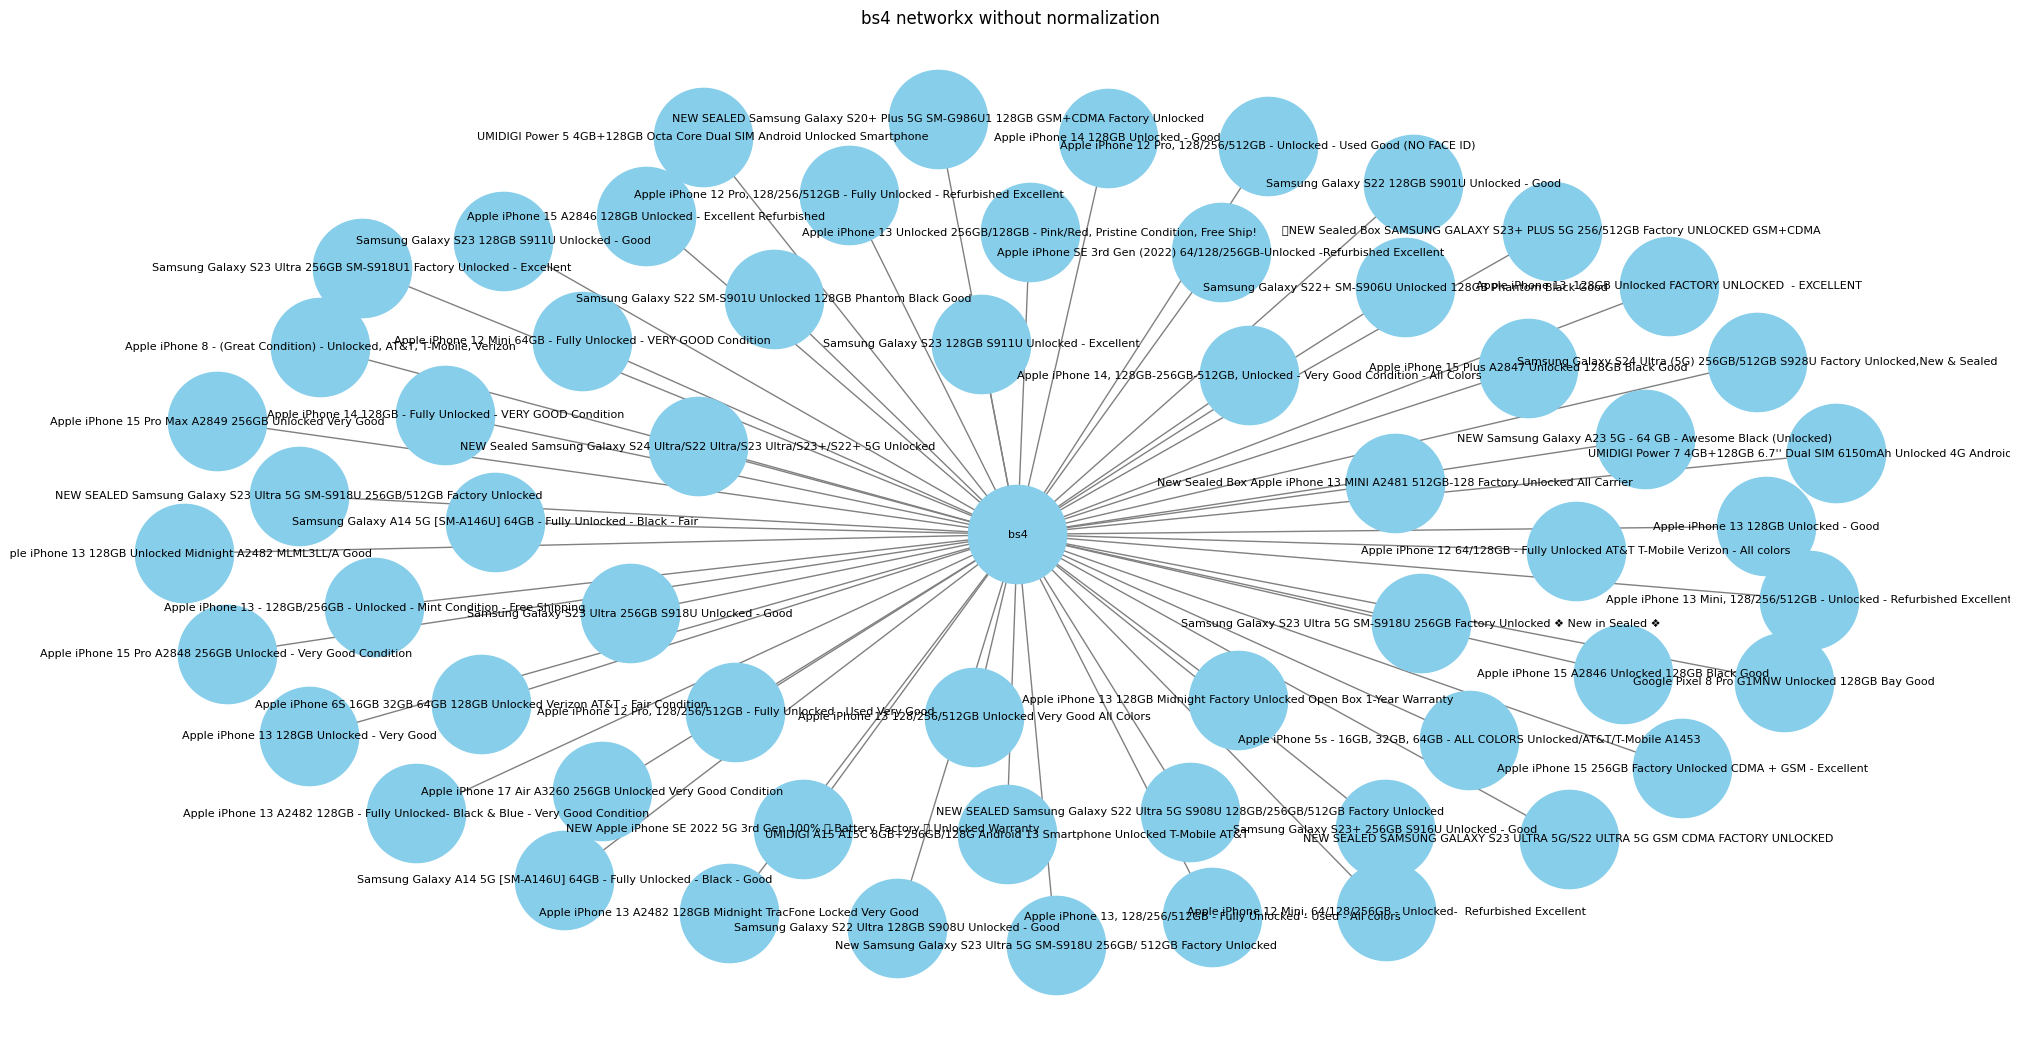

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
G_bs4 = nx.Graph()
for name in df_all[df_all['Source'] == 'bs4']['item_name']:
    G_bs4.add_edge('bs4', name)
plt.figure(figsize=(20, 10))
nx.draw(G_bs4, with_labels=True, node_color='skyblue', font_size=8, node_size=5000, edge_color='gray')
plt.title("bs4 networkx without normalization")
plt.show()

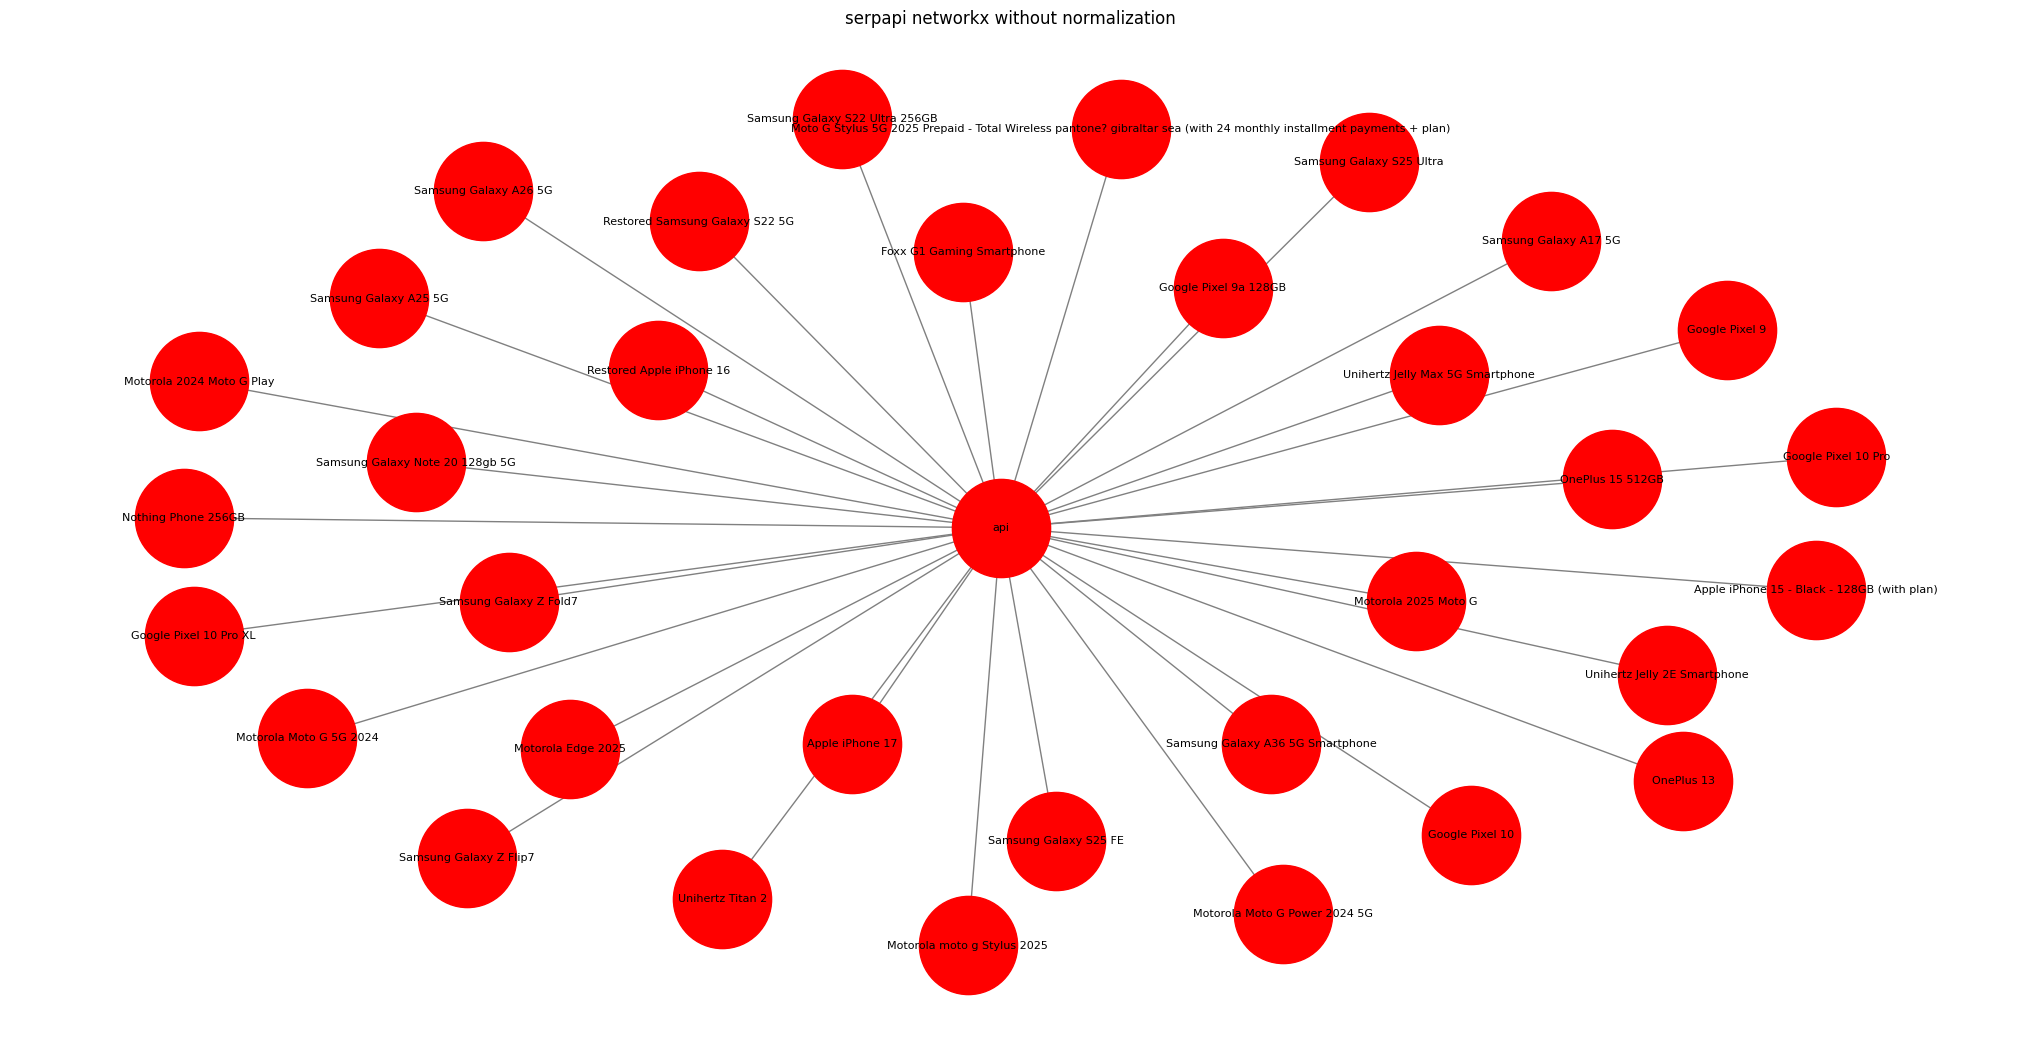

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
G_api = nx.Graph()
for name in df_all[df_all['Source'] == 'serpapi']['item_name']:
    G_api.add_edge('api', name)
plt.figure(figsize=(20, 10))
nx.draw(G_api, with_labels=True, node_color='red', font_size=8, node_size=5000, edge_color='gray')
plt.title("serpapi networkx without normalization")
plt.show()

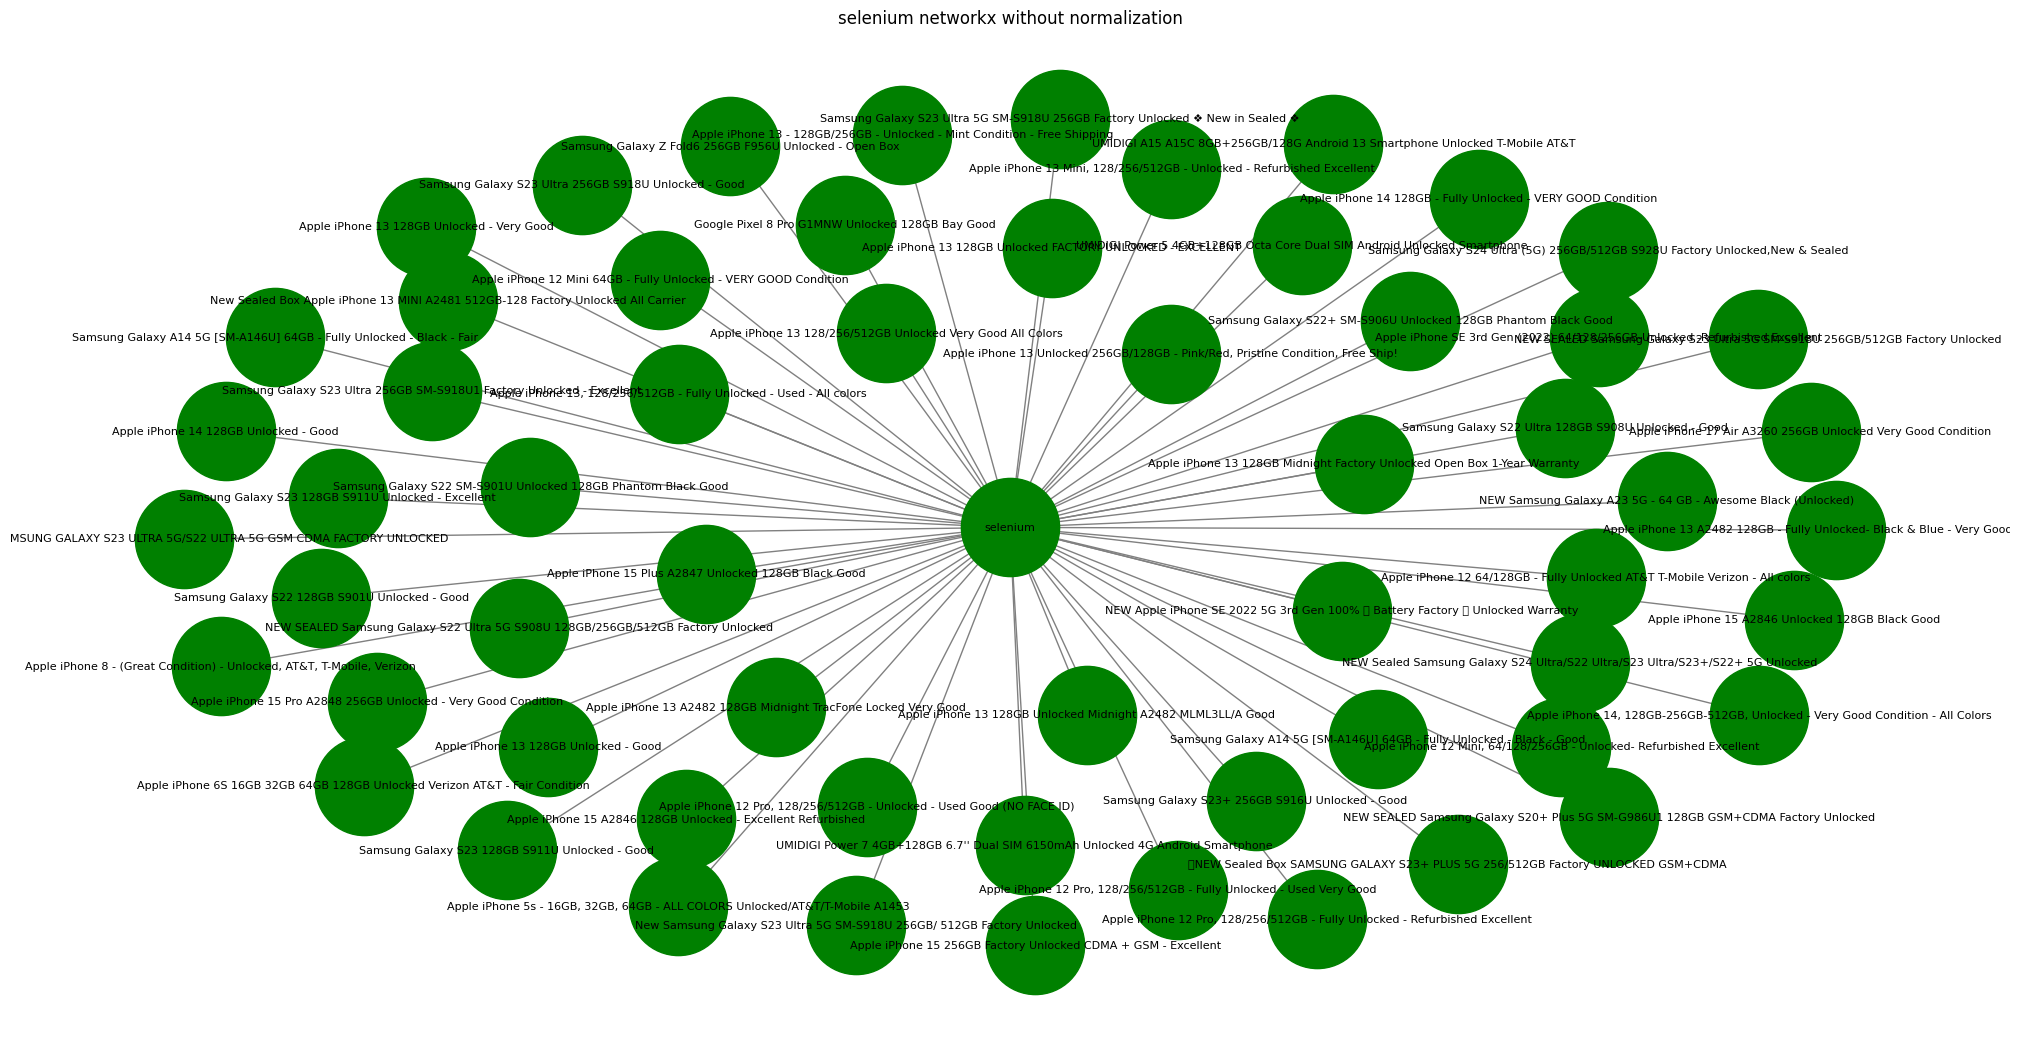

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
G_selenium = nx.Graph()
for name in df_all[df_all['Source'] == 'selenium']['item_name']:
    G_selenium.add_edge('selenium', name)
plt.figure(figsize=(20, 10))
nx.draw(G_selenium, with_labels=True, node_color='green', font_size=8, node_size=5000, edge_color='gray')
plt.title("selenium networkx without normalization")
plt.show()

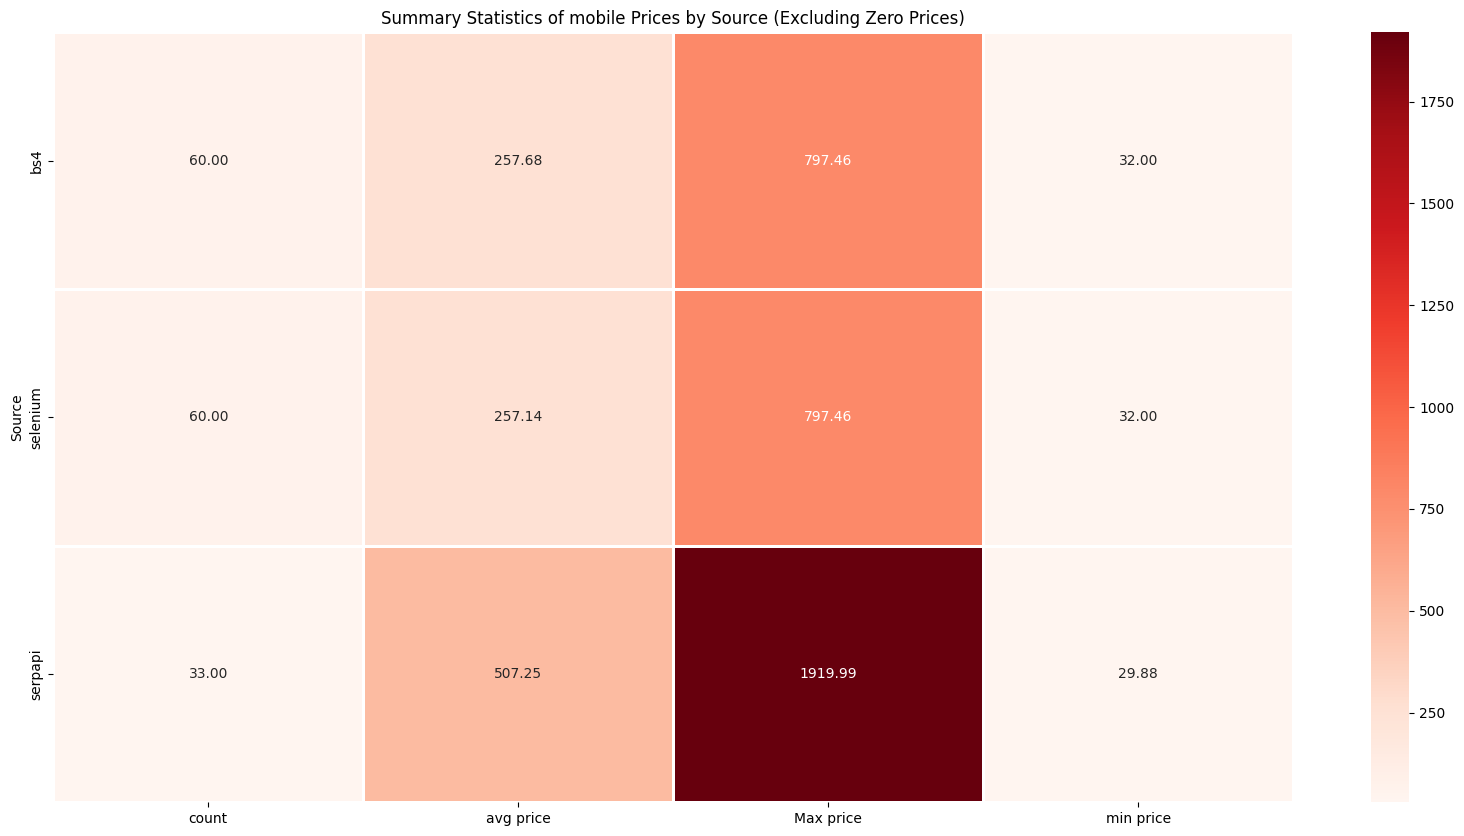

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
filtered_df_all = df_all[df_all['price_cleaned'] > 0]
summary_stats = filtered_df_all.groupby('Source')['price_cleaned'].agg(['count', 'mean', 'max', 'min'])
summary_stats.columns = ['count', 'avg price', 'Max price', 'min price']
plt.figure(figsize=(20, 10))
sns.heatmap(summary_stats, annot=True, cmap="Reds", fmt='.2f', linewidths=1)
plt.title("Summary Statistics of mobile Prices by Source (Excluding Zero Prices)")
plt.show()

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
sources = df_all['Source'].unique()
fig = make_subplots(
    rows=1,
    cols=len(sources),
    subplot_titles=sources
)
for i, src in enumerate(sources):
    df_src = df_all[df_all['Source'] == src]
    fig.add_trace(
        go.Histogram(x=df_src['price_cleaned'], name=src),
        row=1,
        col=i+1
    )
fig.update_layout(title="Price Comparison per Source")

fig.show()

In [ ]:
import plotly.express as px
df_all['index'] = df_all.index
df_all['rank'] = df_all['price_cleaned'].rank()
fig = px.scatter_3d(
    df_all,
    x='index',
    y='price_cleaned',
    z='rank',
    color='Source',
    hover_name='item_name',
    title="3D Comparison"
)

fig.show()

In [ ]:
import plotly.express as px
df_all['name_length'] = df_all['item_name'].apply(len)
df_all['rank'] = df_all['price_cleaned'].rank()
fig = px.scatter_3d(
    df_all,
    x='price_cleaned',
    y='name_length',
    z='rank',
    color='Source',
    hover_name='item_name',
    title="3D Analysis: Price vs Name Complexity vs Rank"
)

fig.show()

In [ ]:
import plotly.express as px
fig = px.box(
    df_all,
    x='Source',
    y='price_cleaned',
    title="Outliers Detection per Source"
)
fig.show()

In [ ]:
print(df_all.groupby('Source')['price_cleaned'].describe())

          count        mean         std    min     25%      50%      75%  \
Source                                                                     
bs4        60.0  257.677167  144.147567  32.00  156.30  235.005  322.635   
selenium   60.0  257.135833  142.859279  32.00  156.30  235.005  322.635   
serpapi    33.0  507.247273  415.499235  29.88  179.99  399.990  749.000   

              max  
Source             
bs4        797.46  
selenium   797.46  
serpapi   1919.99  


In [ ]:
from sklearn.cluster import KMeans
X = df_all[['price_cleaned']]
kmeans = KMeans(n_clusters=3)
df_all['cluster'] = kmeans.fit_predict(X)
fig = px.scatter_3d(
    df_all,
    x='price_cleaned',
    y='name_length',
    z='cluster',
    color='cluster',
    hover_name='item_name',
    title="3D Clustering of Products"
)

fig.show()

In [ ]:
df_all['item_name'] = df_all['item_name'].astype(str).str.lower()
df_all['brand'] = df_all['item_name'].str.extract(
    r'(iphone|samsung|huawei|xiaomi|apple|galaxy)',
    expand=False
)

print(df_all['brand'].value_counts())

brand
apple      70
samsung    56
Name: count, dtype: int64


In [ ]:
import plotly.express as px
fig = px.box(
    df_all,
    x='brand',
    y='price_cleaned',
    title="Price Distribution per Brand"
)
fig.show()

In [ ]:
df_all['brand'] = df_all['item_name'].str.lower()
brands = ['iphone', 'samsung']
for b in brands:
    df_brand = df_all[df_all['brand'].str.contains(b, na=False)].copy()
    df_brand = df_brand.sort_values(by='price_cleaned', ascending=False)
    df_brand.to_csv(f"{b}_products.csv", index=False)
    print(f"{b} saved:", len(df_brand))

iphone saved: 70
samsung saved: 56


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.



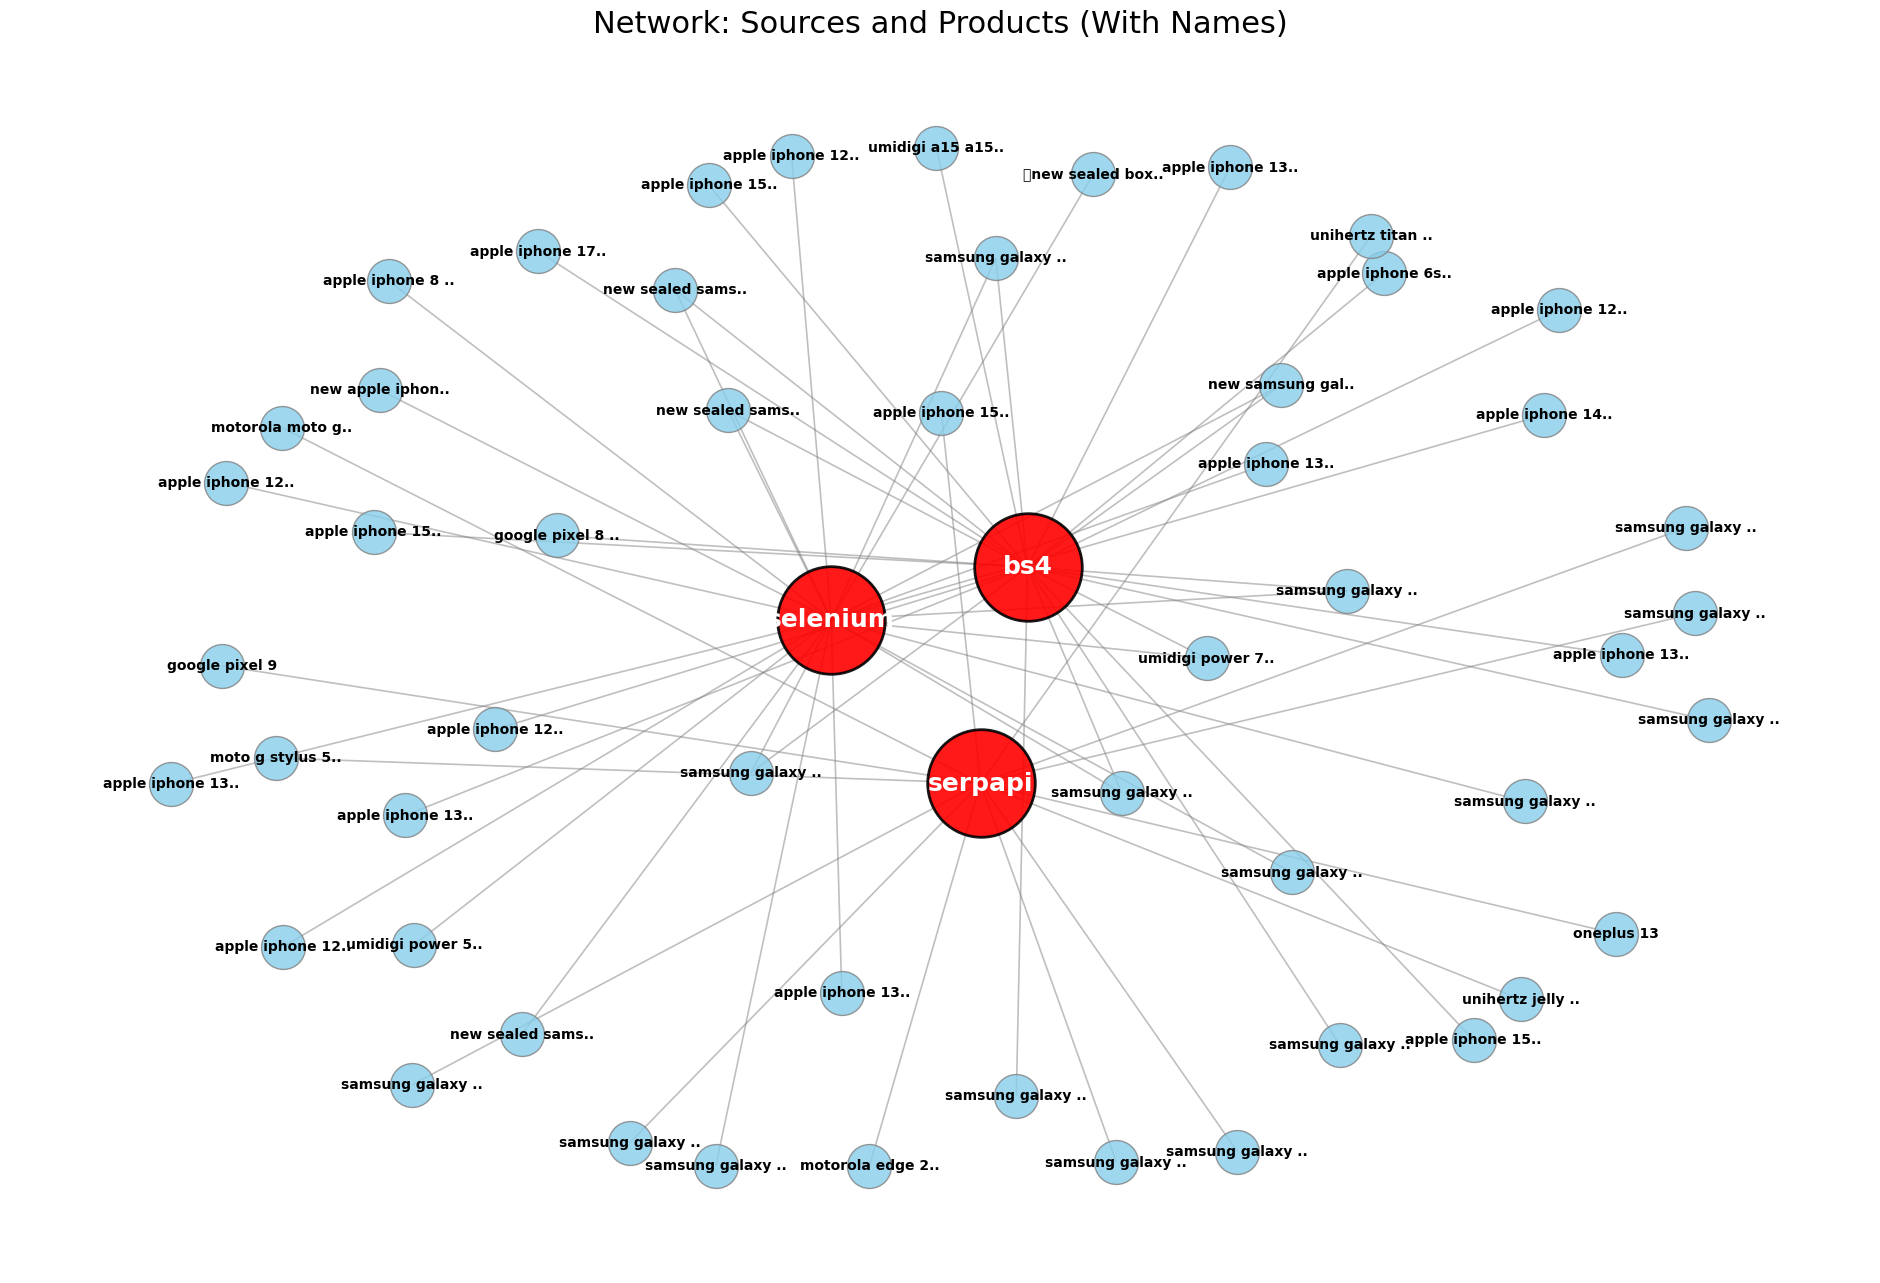

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
df_sample = df_all.sample(n=60, random_state=42)
G = nx.Graph()
for index, row in df_sample.iterrows():
    G.add_edge(row['Source'], row['item_name'])
sources = df_all['Source'].unique()
items = [node for node in G.nodes() if node not in sources]
plt.figure(figsize=(24, 16))
pos = nx.spring_layout(G, k=0.9, iterations=50)
nx.draw_networkx_nodes(G, pos, nodelist=[s for s in sources if s in G.nodes()], node_color='red', node_size=6000, alpha=0.9, edgecolors='black', linewidths=2)
nx.draw_networkx_nodes(G, pos, nodelist=items, node_color='skyblue', node_size=1000, alpha=0.8, edgecolors='gray')
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5, width=1.2)
source_labels = {source: str(source) for source in sources if source in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=source_labels, font_size=18, font_weight='bold', font_color='white')
item_labels = {item: str(item)[:15] + '..' if len(str(item)) > 15 else str(item) for item in items}
nx.draw_networkx_labels(G, pos, labels=item_labels, font_size=10, font_weight='bold', font_color='black')
plt.title("Network: Sources and Products (With Names)", fontsize=22)
plt.axis('off')
plt.show()

In [ ]:
!pip install pyvis

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import re

def extract_storage(name):
    match = re.search(r'(\d+\s*(?:GB|TB|gb|tb))', str(name))
    return match.group(1).replace(" ", "").lower() if match else "unknown"

df_all['storage'] = df_all['item_name'].apply(extract_storage)

le_source = LabelEncoder()
le_brand = LabelEncoder()
le_storage = LabelEncoder()

df_ml = df_all.copy()
df_ml['source_enc'] = le_source.fit_transform(df_ml['Source'])
df_ml['brand_enc'] = le_brand.fit_transform(df_ml['brand'].fillna('unknown'))
df_ml['storage_enc'] = le_storage.fit_transform(df_ml['storage'])

X = df_ml[['source_enc', 'brand_enc', 'storage_enc']]
y = df_ml['price_cleaned']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

output = widgets.Output()

brand_dd = widgets.Dropdown(
    options=sorted(df_ml['brand'].fillna('unknown').unique()),
    description='Brand:',
    style={'description_width': 'initial'}
)

source_dd = widgets.Dropdown(
    options=df_ml['Source'].unique(),
    description='Source:',
    style={'description_width': 'initial'}
)

storage_dd = widgets.Dropdown(
    options=sorted(df_ml['storage'].unique()),
    description='Storage:',
    style={'description_width': 'initial'}
)

predict_btn = widgets.Button(
    description='Predict Price',
    button_style='success',
    layout=widgets.Layout(width='200px')
)

def on_predict_clicked(b):
    with output:
        clear_output()
        try:
            brand_idx = le_brand.transform([brand_dd.value])[0]
            source_idx = le_source.transform([source_dd.value])[0]
            storage_idx = le_storage.transform([storage_dd.value])[0]

            prediction = model.predict([[source_idx, brand_idx, storage_idx]])

            print(f" Analysis complete:")
            print(f" Predicted Price: {prediction[0]:,.2f} $")
            print(f" Based on Storage: {storage_dd.value}")
        except Exception as e:
            print(f"Error during prediction: {e}")

predict_btn.on_click(on_predict_clicked)

header = widgets.HTML("<h2> Price Predictor (Storage-Based Model)</h2>")
ui = widgets.VBox([header, brand_dd, source_dd, storage_dd, predict_btn])
display(ui, output)

Output()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import re
import plotly.graph_objects as go
df_ml = df_all.copy()
df_ml['brand'] = df_ml['brand'].fillna('unknown')
def get_storage(text):
    m = re.search(r'(\d+\s*(?:GB|TB|gb|tb))', str(text))
    if m:
        return m.group(1).replace(" ", "").lower()
    return "unknown"
df_ml['storage'] = df_ml['item_name'].apply(get_storage)
le_src = LabelEncoder()
df_ml['Source_enc'] = le_src.fit_transform(df_ml['Source'])
le_brnd = LabelEncoder()
df_ml['brand_enc'] = le_brnd.fit_transform(df_ml['brand'])
le_strg = LabelEncoder()
df_ml['storage_enc'] = le_strg.fit_transform(df_ml['storage'])
X = df_ml[['Source_enc', 'brand_enc', 'storage_enc']]
y = df_ml['price_cleaned']
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X, y)
out = widgets.Output()
b_drop = widgets.Dropdown(options=sorted(df_ml['brand'].unique()), description='Brand:')
s_drop = widgets.Dropdown(options=df_ml['Source'].unique(), description='Source:')
st_drop = widgets.Dropdown(options=sorted(df_ml['storage'].unique()), description='Storage:')
price_in = widgets.FloatText(value=0.0, description='Found Price:')
btn = widgets.Button(description='Analyze Deal', button_style='success')
def check_deal(b):
    with out:
        clear_output()
        try:
            b_val = le_brnd.transform([b_drop.value])[0]
            s_val = le_src.transform([s_drop.value])[0]
            st_val = le_strg.transform([st_drop.value])[0]
            pred = model.predict([[s_val, b_val, st_val]])[0]
            my_price = price_in.value
            print("Analysis complete:")
            print(f"Fair Market Price: {pred:,.2f} $")
            if my_price > 0:
                if my_price < pred:
                    status = "GREAT DEAL (Below Market Value)"
                elif my_price > pred:
                    status = "OVERPRICED (Above Market Value)"
                else:
                    status = "FAIR PRICE"
                print(f"Your Found Price: {my_price:,.2f} $")
                print(f"Deal Status: {status}")
                gauge = go.Figure(go.Indicator(
                    mode="gauge+number+delta",
                    value=my_price,
                    domain={'x': [0, 1], 'y': [0, 1]},
                    title={'text': "Deal Analyzer", 'font': {'size': 20}},
                    delta={'reference': pred, 'increasing': {'color': "red"}, 'decreasing': {'color': "green"}},
                    gauge={
                        'axis': {'range': [None, pred * 1.5], 'tickwidth': 1, 'tickcolor': "darkblue"},
                        'bar': {'color': "black"},
                        'bgcolor': "white",
                        'borderwidth': 2,
                        'bordercolor': "gray",
                        'steps': [
                            {'range': [0, pred * 0.9], 'color': "lightgreen"},
                            {'range': [pred * 0.9, pred * 1.1], 'color': "lightyellow"},
                            {'range': [pred * 1.1, pred * 1.5], 'color': "salmon"}],
                        'threshold': {'line': {'color': "blue", 'width': 4}, 'thickness': 0.75, 'value': pred}}))
                gauge.show()
            else:
                print("Enter a 'Found Price' above 0 to see the interactive deal gauge.")
        except Exception as e:
            print(f"Error: {e}")

btn.on_click(check_deal)

hdr = widgets.HTML("<h2>Smart Deal Analyzer</h2>")
display(widgets.VBox([hdr, b_drop, s_drop, st_drop, price_in, btn]), out)

Output()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
brands_list = ['All'] + sorted(df_all['brand'].fillna('unknown').unique().tolist())
brand_filter = widgets.Dropdown(options=brands_list, description='Filter Brand:')
btn_data = widgets.Button(description='View Data', button_style='info')
btn_nulls = widgets.Button(description='Check Nulls', button_style='warning')
out_display = widgets.Output()
def view_data_clicked(b):
    with out_display:
        clear_output()
        if brand_filter.value == 'All':
            df_view = df_all.head(10)
        else:
            df_view = df_all[df_all['brand'] == brand_filter.value].head(10)
        print(f"Showing sample data for: {brand_filter.value}")
        display(df_view)
def check_nulls_clicked(b):
    with out_display:
        clear_output()
        print("Missing Values in the Dataset:")
        display(pd.DataFrame(df_all.isnull().sum(), columns=['Missing Count']))

btn_data.on_click(view_data_clicked)
btn_nulls.on_click(check_nulls_clicked)
controls = widgets.HBox([brand_filter, btn_data, btn_nulls])
header = widgets.HTML("<h2>Data Exploration & Cleaning Dashboard</h2>")

display(widgets.VBox([header, controls, out_display]))

In [ ]:
import plotly.io as pio
pio.renderers.default = 'colab'
import plotly.express as px
brand_data = df_all['brand'].value_counts().reset_index()
brand_data.columns = ['Brand Name', 'Count']
fig1 = px.bar(brand_data, x='Brand Name', y='Count', title='Handsets by Brand')
fig1.show()

In [ ]:
import plotly.express as px
top_brands = df_all['brand'].value_counts().nlargest(6)
brand_counts = df_all['brand'].value_counts().reset_index()
brand_counts.columns = ['brand', 'count']
fig = px.pie(brand_counts,
             values='count',
             names='brand',

             hole=0.6)
fig.update_traces(textinfo='percent+label')
fig.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128275 (\N{OPEN LOCK}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.



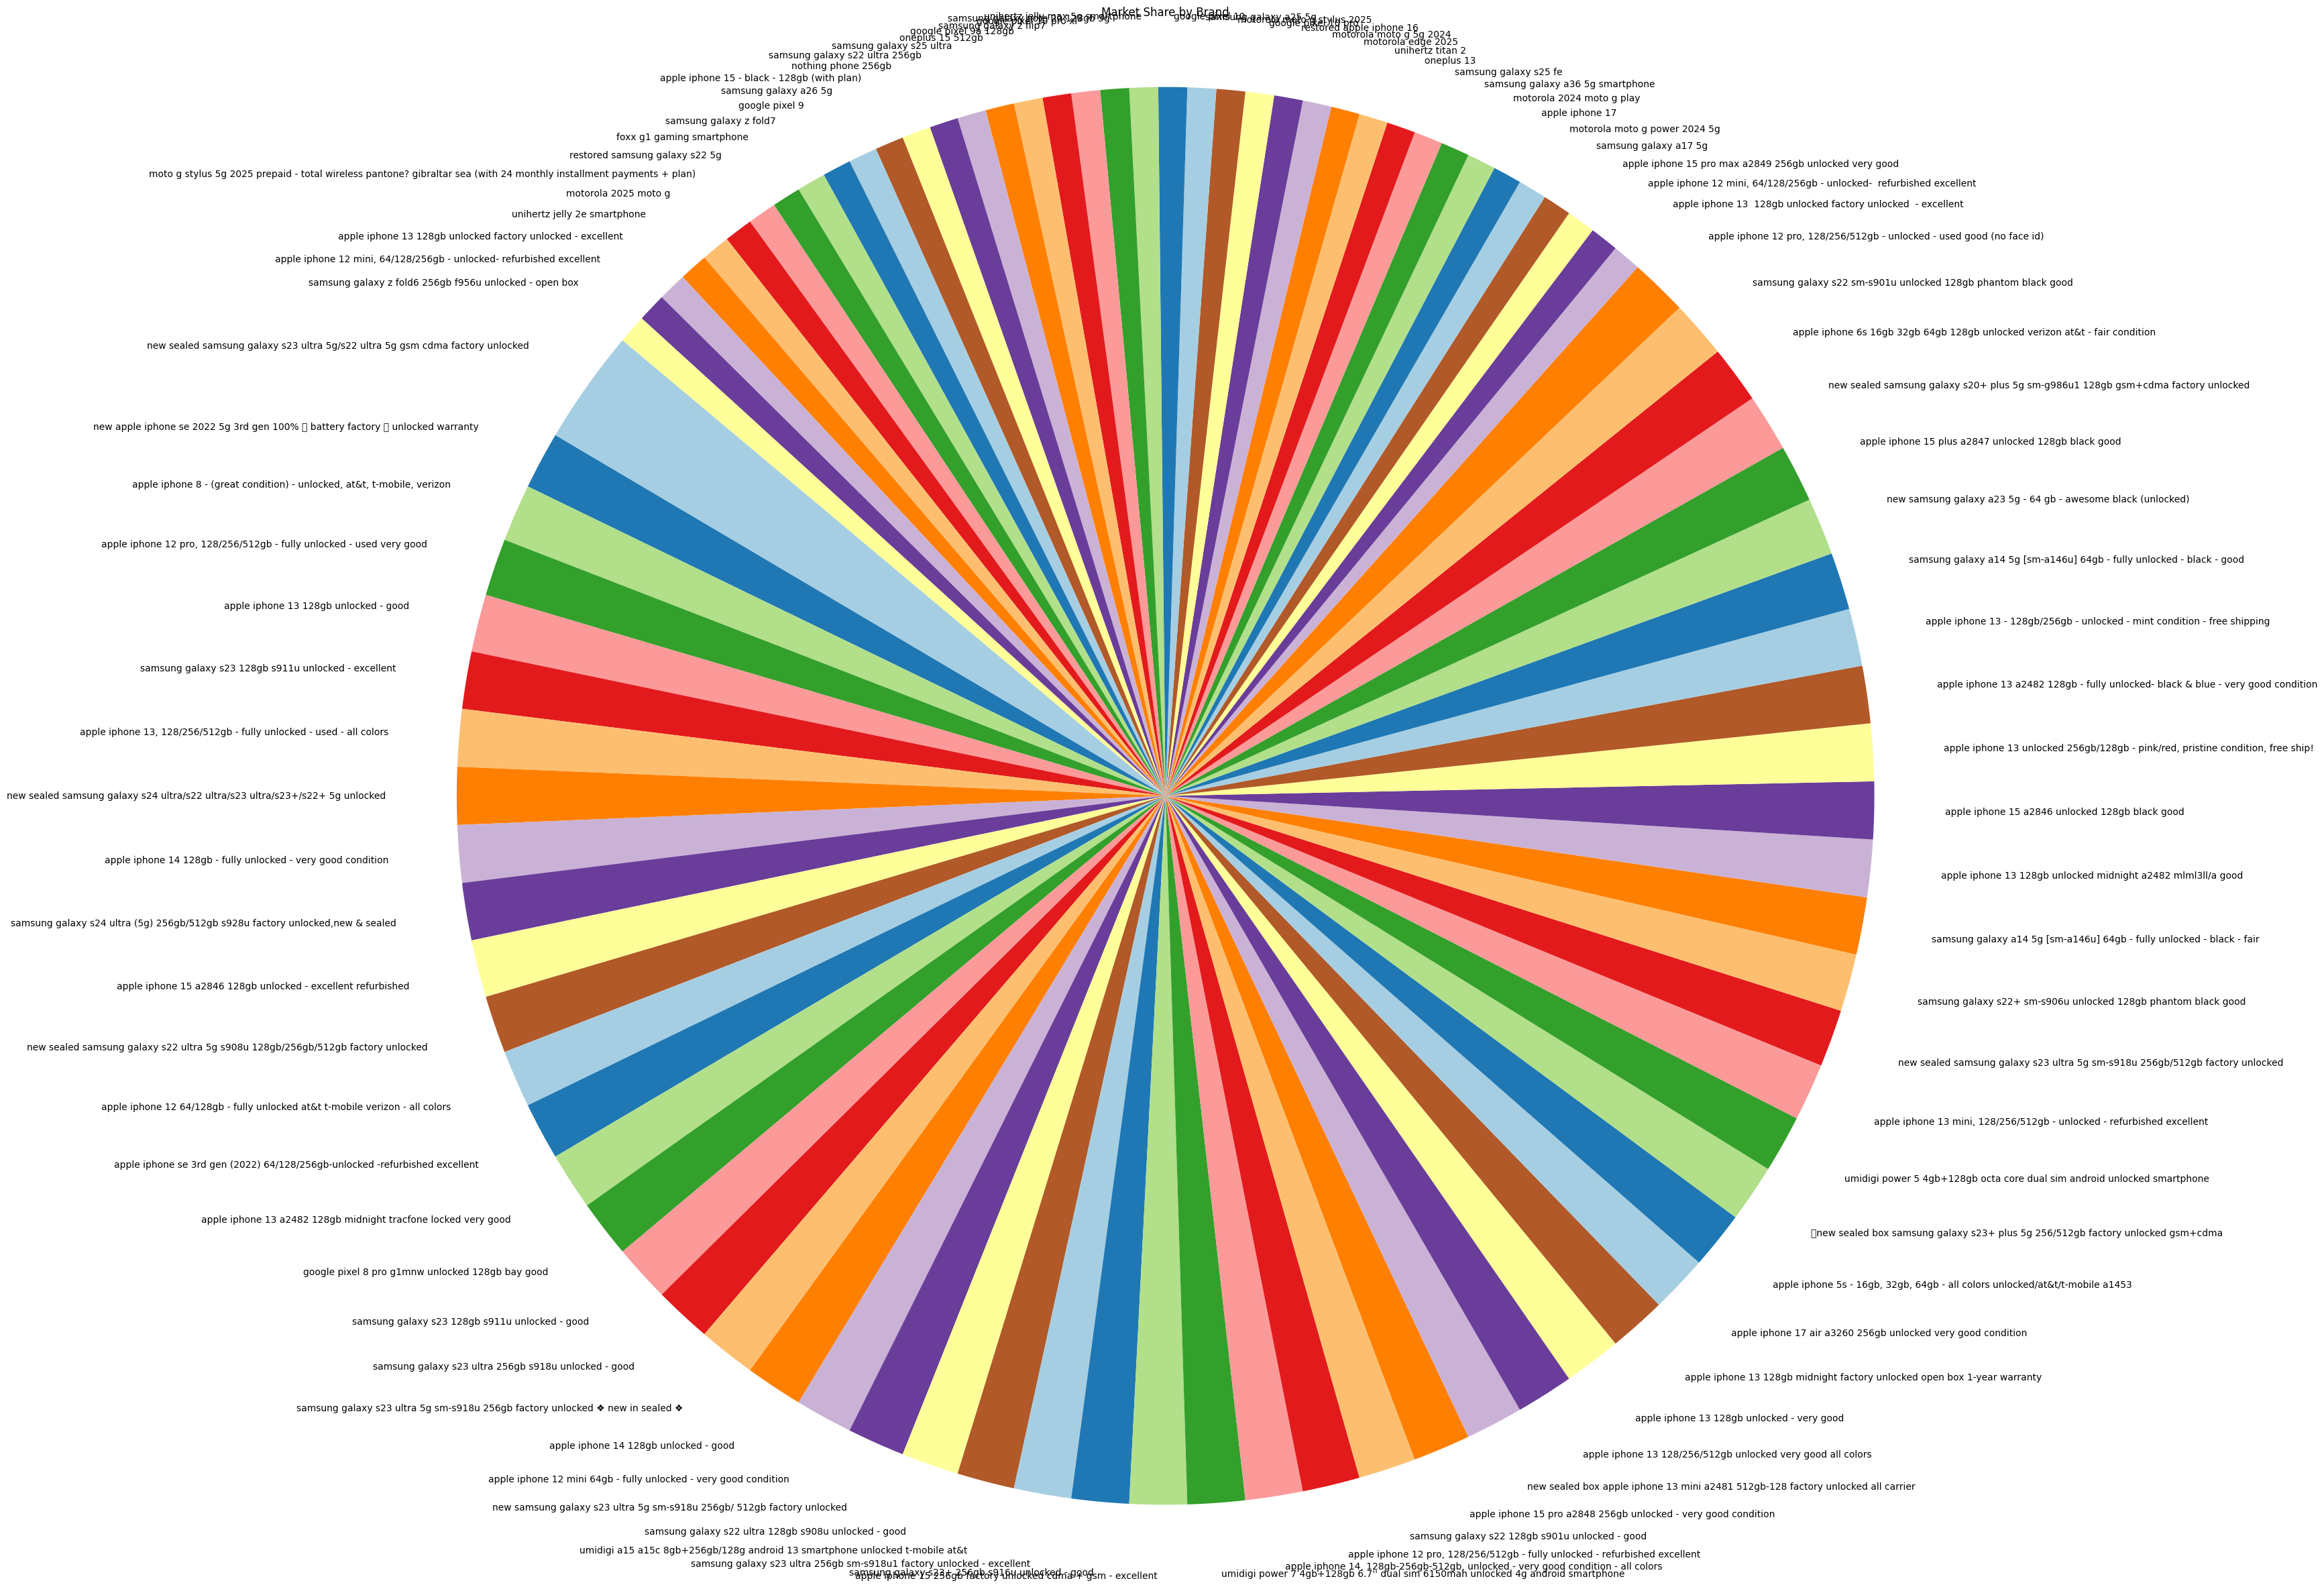

In [ ]:
import matplotlib.pyplot as plt
brand_data = df_all['brand'].value_counts()
plt.figure(figsize=(30, 30))
plt.pie(brand_data,
        labels=brand_data.index,

        startangle=140,
        colors=plt.cm.Paired.colors)
plt.title('Market Share by Brand')
plt.axis('equal')
plt.show()